## Import Libraries

The required Python libraries for data manipulation, visualization, and machine learning tasks were imported.

In [103]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Load Dataset

In [104]:
df = pd.read_csv("german_credit_data.csv")

The German Credit dataset was loaded into a Pandas DataFrame for exploratory analysis, preprocessing, and predictive modeling.

## Data Overview

In [105]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [107]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


The dataset contains 1,000 customer records and 11 variables describing demographic characteristics, financial status, and credit-related information. Initial inspection revealed missing values in the Saving accounts and Checking account variables. The dataset includes both numerical and categorical features, making it suitable for classification-based credit risk analysis. Numerical variables such as Age, Credit amount, and Duration show substantial variation across customers, suggesting potentially important predictors for credit risk assessment.

## Missing Value Analysis

In [108]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [109]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean()*100,2)
})

missing

,Missing Values,Missing Percentage
Unnamed: 0,0,0.0
Age,0,0.0
Sex,0,0.0
Job,0,0.0
Housing,0,0.0
Saving accounts,183,18.3
Checking account,394,39.4
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0


In [110]:
df["Saving accounts"].value_counts(dropna=False)

Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [111]:

df["Checking account"].value_counts(dropna=False)

Checking account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64

Missing value analysis revealed that only two variables contain missing observations. The Saving accounts variable has 183 missing values (18.3%), while the Checking account variable has 394 missing values (39.4%). All remaining variables are complete. Since missing values represent a substantial proportion of these variables, an appropriate imputation strategy will be applied during data cleaning.

## Data Cleaning 

Data cleaning was performed to remove non-informative variables and handle missing values before exploratory analysis and model development.

In [112]:
df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


The Unnamed: 0 column was removed because it represents an automatically generated index and does not provide any meaningful information for credit risk analysis. The dataset now contains only relevant predictive variables.

## Handling Missing Values

Missing values were handled before model development to ensure data quality and prevent information loss. Since the proportion of missing values was substantial, records were retained and missing categories were treated as a separate group.

In [113]:
df["Saving accounts"] = df["Saving accounts"].fillna("no_account")

df["Checking account"] = df["Checking account"].fillna("no_account")

In [114]:
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

Missing values in the Saving accounts and Checking account variables were replaced with the category "no_account". This approach preserves all observations while distinguishing customers who do not have a savings or checking account from those with existing account types. After imputation, no missing values remained in the dataset.

## Target Variable Analysis

In [115]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [116]:
df["Risk"].value_counts(normalize=True)

Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64

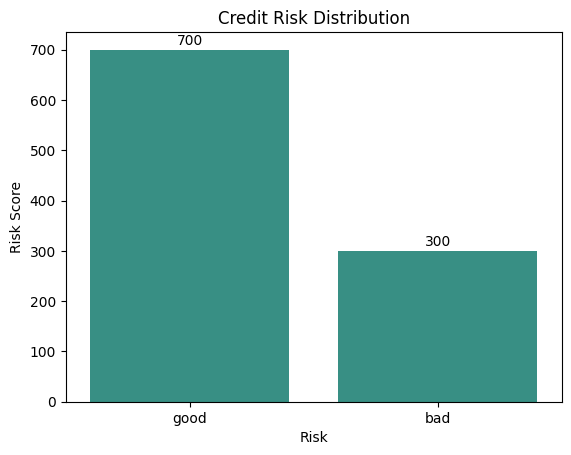

In [117]:
ax = sns.countplot(
    data=df,
    x="Risk",
    color="#2a9d8f"
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (
            p.get_x() + p.get_width()/2,
            p.get_height()+10
        ),
        ha="center"
    )

plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Risk Score")

plt.show()

The target variable is moderately imbalanced. Approximately 70% of customers belong to the good credit risk class, while 30% belong to the bad credit risk class. Although the imbalance is not extreme, it may influence model performance and should be considered during model evaluation.

## Exploratory Data Analysis (EDA)

#### Sex vs Risk

In [118]:
pd.crosstab(
    df["Sex"],
    df["Risk"],
    normalize="index"
)*100

Risk,bad,good
Sex,,
female,35.161290,64.838710
male,27.681159,72.318841


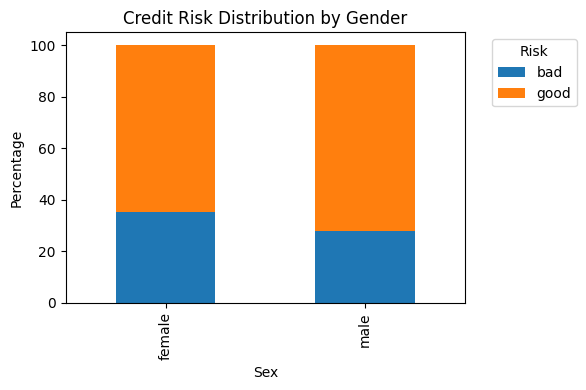

In [119]:
risk_by_sex = pd.crosstab(
    df["Sex"],
    df["Risk"],
    normalize="index"
)*100

risk_by_sex.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.ylabel("Percentage")
plt.title("Credit Risk Distribution by Gender")

plt.legend(
    title="Risk",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Female customers exhibit a higher proportion of bad credit risk (35.2%) compared to male customers (27.7%). Conversely, male customers show a larger share of good credit risk cases. This finding suggests that gender may have some predictive value in distinguishing credit risk profiles within the dataset.

#### Housing vs Risk

The relationship between housing status and credit risk was examined to determine whether home ownership characteristics are associated with creditworthiness.

In [120]:
housing_risk = pd.crosstab(
    df["Housing"],
    df["Risk"],
    normalize="index"
)*100

housing_risk

Risk,bad,good
Housing,,
free,40.740741,59.259259
own,26.086957,73.913043
rent,39.106145,60.893855


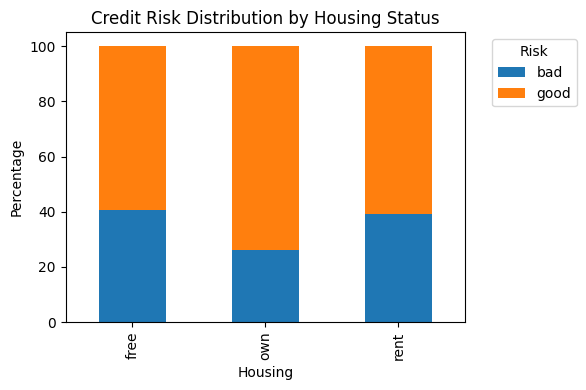

In [121]:
housing_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.ylabel("Percentage")
plt.title("Credit Risk Distribution by Housing Status")

plt.legend(
    title="Risk",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Homeowners exhibit the lowest proportion of bad credit risk cases (26.1%), while customers living rent-free (40.7%) and renters (39.1%) show substantially higher risk levels. The results suggest that housing status may be an important indicator of financial stability, with home ownership being associated with lower credit risk.

#### Saving Account vs Risk

The relationship between savings account status and credit risk was examined to determine whether customers with different levels of savings exhibit different risk profiles.

In [122]:
saving_risk = pd.crosstab(
    df["Saving accounts"],
    df["Risk"],
    normalize="index"
)*100

saving_risk

Risk,bad,good
Saving accounts,,
little,35.986733,64.013267
moderate,33.009709,66.990291
no_account,17.486339,82.513661
quite rich,17.460317,82.539683
rich,12.500000,87.500000


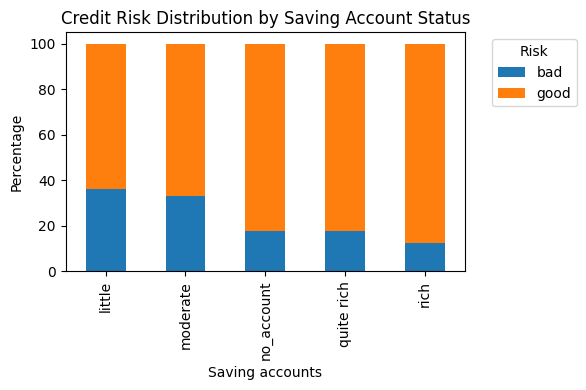

In [123]:
saving_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.ylabel("Percentage")
plt.title("Credit Risk Distribution by Saving Account Status")

plt.legend(
    title="Risk",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Customers with lower savings levels exhibit substantially higher credit risk. The bad credit risk rate reaches 36.0% among customers with little savings and 33.0% among those with moderate savings. In contrast, customers with rich savings accounts show the lowest risk level (12.5%). Overall, the results suggest a negative relationship between savings level and credit risk.

#### Checking Account vs Risk

The relationship between checking account status and credit risk was analyzed to investigate whether customers with different checking account balances exhibit different risk characteristics.

In [124]:
checking_risk = pd.crosstab(
    df["Checking account"],
    df["Risk"],
    normalize="index"
)*100

checking_risk

Risk,bad,good
Checking account,,
little,49.270073,50.729927
moderate,39.033457,60.966543
no_account,11.675127,88.324873
rich,22.222222,77.777778


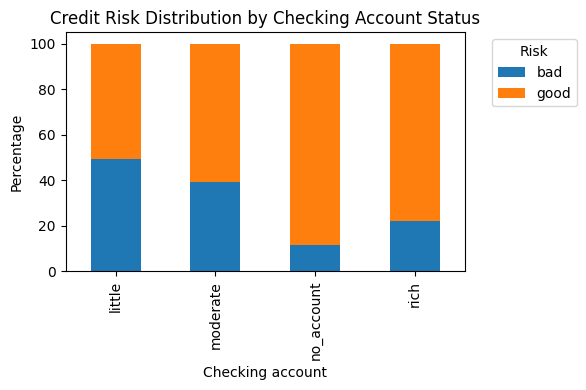

In [125]:
checking_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(6,4)
)

plt.ylabel("Percentage")
plt.title("Credit Risk Distribution by Checking Account Status")

plt.legend(
    title="Risk",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Customers with little checking account balances exhibited the highest credit risk rate (49.3%), followed by those with moderate balances (39.0%). In contrast, customers without a checking account showed the lowest proportion of bad credit risk cases (11.7%). This finding suggests that checking account status is strongly associated with credit risk and may serve as an important predictor in credit risk assessment.

#### Purpose vs Risk

The relationship between loan purpose and credit risk was examined to identify whether certain borrowing purposes are associated with higher levels of credit risk.

In [126]:
df["Purpose"].value_counts()

Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

In [127]:
df["Purpose"].value_counts(normalize=True)*100

Purpose
car                    33.7
radio/TV               28.0
furniture/equipment    18.1
business                9.7
education               5.9
repairs                 2.2
domestic appliances     1.2
vacation/others         1.2
Name: proportion, dtype: float64

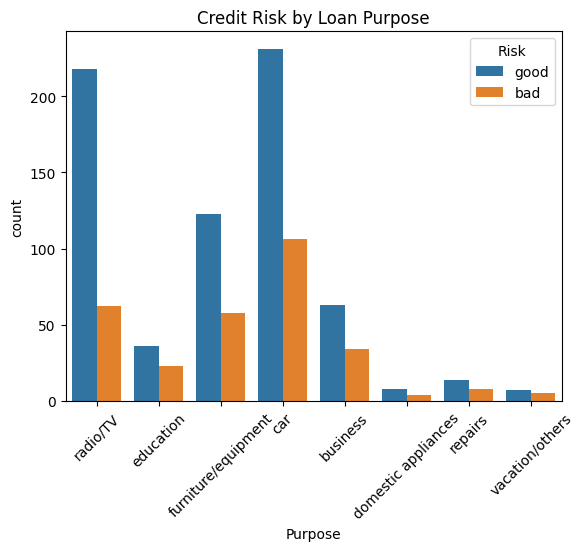

In [128]:
sns.countplot(
    data=df,
    x="Purpose",
    hue="Risk"
)

plt.title("Credit Risk by Loan Purpose")
plt.xticks(rotation=45)
plt.show()

In [129]:
purpose_risk = pd.crosstab(
    df["Purpose"],
    df["Risk"],
    normalize="index"
)*100

purpose_risk

Risk,bad,good
Purpose,,
business,35.051546,64.948454
car,31.454006,68.545994
domestic appliances,33.333333,66.666667
education,38.983051,61.016949
furniture/equipment,32.044199,67.955801
radio/TV,22.142857,77.857143
repairs,36.363636,63.636364
vacation/others,41.666667,58.333333


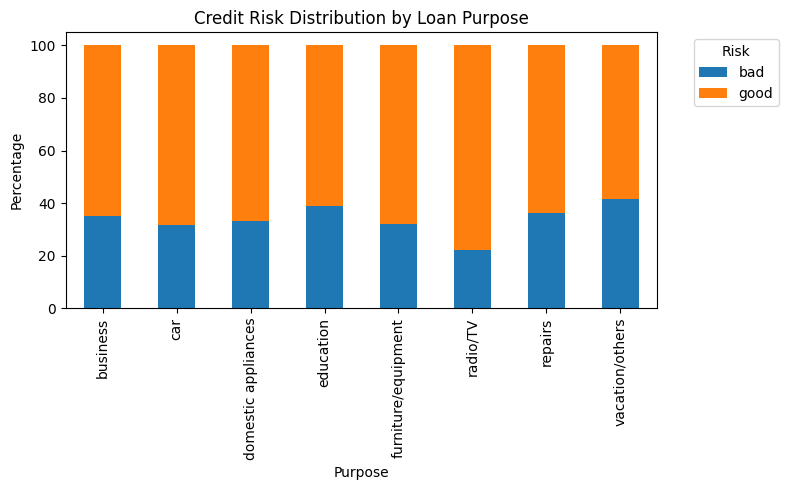

In [130]:
purpose_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("Percentage")
plt.title("Credit Risk Distribution by Loan Purpose")

plt.legend(
    title="Risk",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Although the vacation/others category exhibited the highest bad credit risk rate (41.7%), this group contains only 12 observations and should therefore be interpreted with caution. Among categories with more substantial sample sizes, education (39.0%), business (35.1%), and car loans (31.5%) showed relatively higher levels of credit risk. In contrast, radio/TV loans had the lowest bad risk rate (22.1%). These findings suggest that borrowing purpose may be associated with differences in customer credit risk profiles.

#### Age vs Risk

The relationship between customer age and credit risk was examined to determine whether borrowers in different age groups exhibit different risk profiles.

In [131]:
df["Age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [132]:
df.groupby("Risk")["Age"].agg(
    ["count","mean","median","min","max"]
)

,count,mean,median,min,max
Risk,,,,,
bad,300,33.963333,31.0,19,74
good,700,36.224286,34.0,19,75


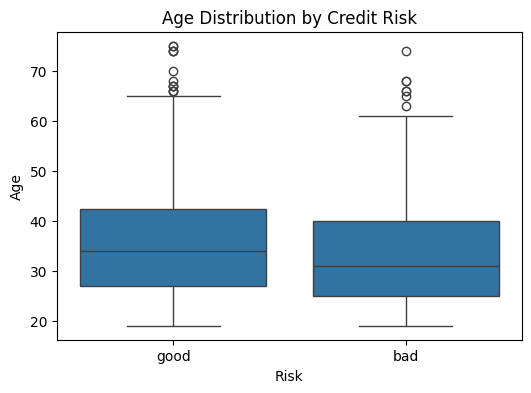

In [133]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Risk",
    y="Age"
)

plt.title("Age Distribution by Credit Risk")
plt.show()

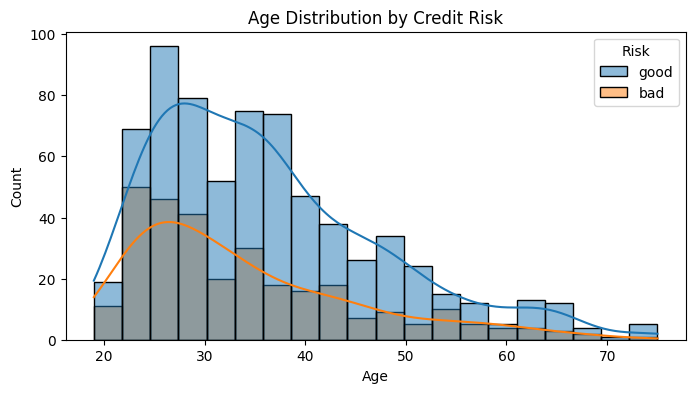

In [134]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x="Age",
    hue="Risk",
    kde=True,
    bins=20
)

plt.title("Age Distribution by Credit Risk")
plt.show()

In [135]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18,30,40,50,60,80],
    labels=[
        "18-30",
        "31-40",
        "41-50",
        "51-60",
        "60+"
    ]
)

In [136]:
df["Age_Group"].value_counts()

Age_Group
18-30    411
31-40    315
41-50    161
51-60     68
60+       45
Name: count, dtype: int64

In [137]:
age_risk = pd.crosstab(
    df["Age_Group"],
    df["Risk"],
    normalize="index"
)*100

age_risk

Risk,bad,good
Age_Group,,
18-30,36.009732,63.990268
31-40,25.396825,74.603175
41-50,25.465839,74.534161
51-60,30.882353,69.117647
60+,22.222222,77.777778


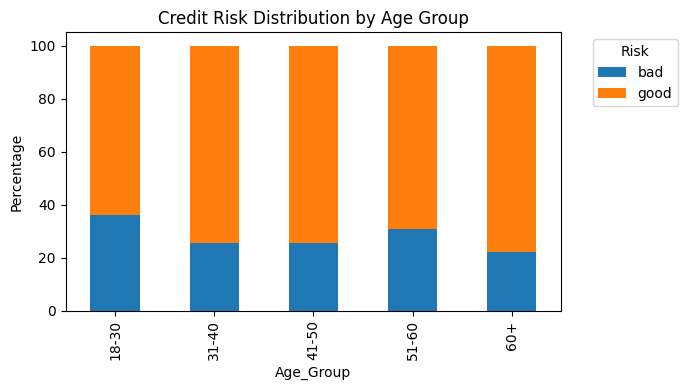

In [138]:
age_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.ylabel("Percentage")
plt.title("Credit Risk Distribution by Age Group")

plt.legend(
    title="Risk",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

The customer population is concentrated in the 18–30 and 31–40 age groups, as also observed in the age distribution histogram. The highest proportion of bad credit risk cases is observed among customers aged 18–30 (36.0%), while customers aged 60 and above exhibit the lowest bad credit risk rate (22.2%). These findings suggest that younger borrowers tend to present higher credit risk, whereas older customers generally demonstrate more reliable credit behavior.

#### Duration vs Risk 

The relationship between loan duration and credit risk was examined to determine whether longer repayment periods are associated with higher levels of credit risk.

Kredi süresi ile kredi riski arasındaki ilişki incelenmiştir. Amaç, daha uzun vadeli kredilerin daha yüksek risk taşıyıp taşımadığını belirlemektir.

In [139]:
df["Duration"].describe()

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: Duration, dtype: float64

In [140]:
df.groupby("Risk")["Duration"].agg(
    ["count","mean","median","min","max"]
)

,count,mean,median,min,max
Risk,,,,,
bad,300,24.860000,24.0,6,72
good,700,19.207143,18.0,4,60


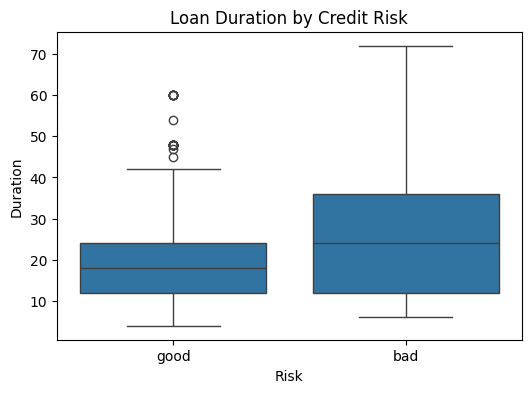

In [141]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Risk",
    y="Duration"
)

plt.title("Loan Duration by Credit Risk")
plt.show()

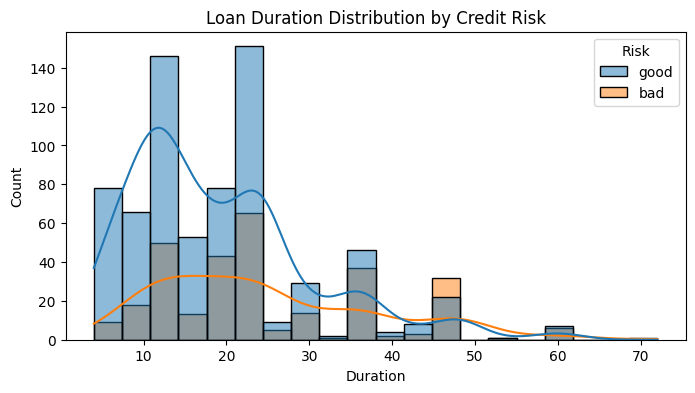

In [142]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x="Duration",
    hue="Risk",
    kde=True,
    bins=20
)

plt.title("Loan Duration Distribution by Credit Risk")
plt.show()

To better understand the relationship between repayment period and credit risk, loan durations were grouped into categories representing short-, medium-, and long-term loans.

In [143]:
df["Duration_Group"] = pd.cut(
    df["Duration"],
    bins=[0,12,24,36,72],
    labels=[
        "Short (<=12)",
        "Medium (13-24)",
        "Long (25-36)",
        "Very Long (37+)"
    ]
)

In [144]:
df["Duration_Group"].value_counts()

Duration_Group
Medium (13-24)     411
Short (<=12)       359
Long (25-36)       143
Very Long (37+)     87
Name: count, dtype: int64

In [145]:
duration_risk = pd.crosstab(
    df["Duration_Group"],
    df["Risk"],
    normalize="index"
)*100

duration_risk

Risk,bad,good
Duration_Group,,
Short (<=12),21.169916,78.830084
Medium (13-24),29.683698,70.316302
Long (25-36),39.860140,60.139860
Very Long (37+),51.724138,48.275862


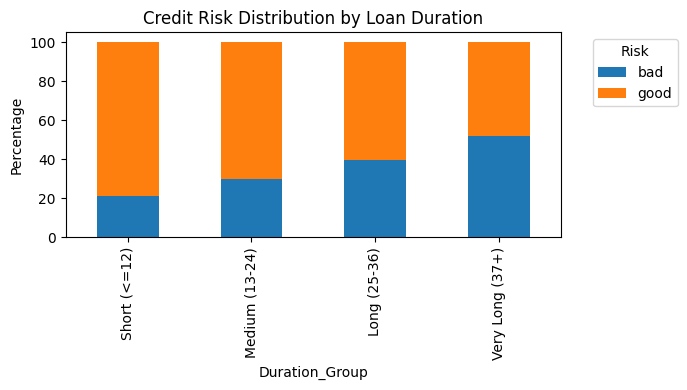

In [146]:
duration_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.ylabel("Percentage")
plt.title("Credit Risk Distribution by Loan Duration")
plt.legend(
    title="Risk",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Loan duration appears to be a strong predictor of credit risk. Customers classified as bad risk have a substantially longer average repayment period (24.9 months) compared to good-risk customers (19.2 months). The percentage analysis further reveals a clear upward trend in risk as loan duration increases. While only 21.2% of short-term loans (≤12 months) are classified as bad risk, this proportion rises to 51.7% for loans exceeding 37 months. These findings suggest that longer repayment periods are strongly associated with higher credit risk.

Kredi süresi, kredi riskini açıklayan en güçlü değişkenlerden biri olarak görünmektedir. Kötü kredi grubundaki müşterilerin ortalama kredi süresi 24.9 ay iken, iyi kredi grubunda bu değer 19.2 aydır. Yüzdesel analiz incelendiğinde kredi süresi uzadıkça kötü kredi oranının düzenli olarak arttığı görülmektedir. Kısa vadeli kredilerde (≤12 ay) kötü kredi oranı %21.2 seviyesindeyken, 37 ay ve üzerindeki kredilerde bu oran %51.7'ye yükselmektedir. Bu sonuçlar, uzun vadeli kredilerin daha yüksek kredi riski taşıdığını göstermektedir.

#### Credit Amount vs Risk

The relationship between loan amount and credit risk was examined to determine whether customers requesting larger loans exhibit higher levels of credit risk.

Kredi tutarı ile kredi riski arasındaki ilişki incelenmiştir. Amaç, daha yüksek kredi tutarı talep eden müşterilerin daha yüksek risk taşıyıp taşımadığını belirlemektir.

In [147]:
df["Credit amount"].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64

In [148]:
df.groupby("Risk")["Credit amount"].agg(
    ["count","mean","median","min","max"]
)

,count,mean,median,min,max
Risk,,,,,
bad,300,3938.126667,2574.5,433,18424
good,700,2985.457143,2244.0,250,15857


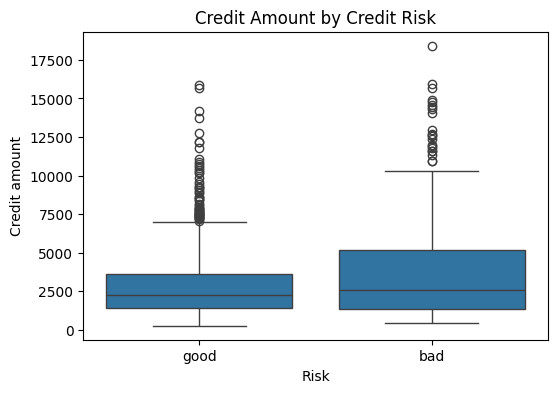

In [149]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Risk",
    y="Credit amount"
)

plt.title("Credit Amount by Credit Risk")
plt.show()

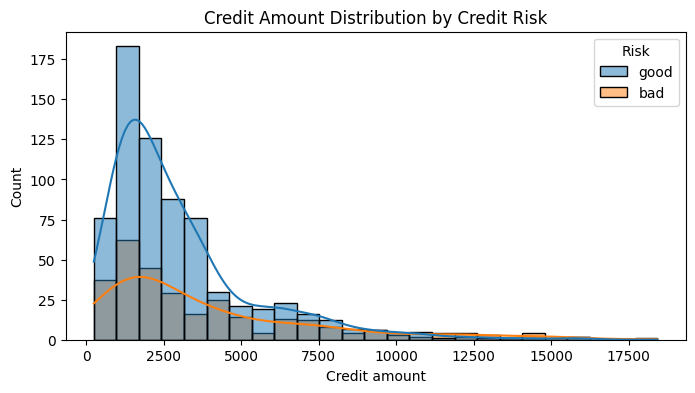

In [150]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x="Credit amount",
    hue="Risk",
    kde=True,
    bins=25
)

plt.title("Credit Amount Distribution by Credit Risk")
plt.show()

To better evaluate the effect of loan size on credit risk, credit amounts were grouped into categories representing small, medium, large, and very large loans.

In [151]:
df["Credit_Group"] = pd.qcut(
    df["Credit amount"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [152]:
df["Credit_Group"].value_counts()

Credit_Group
Low          250
Medium       250
High         250
Very High    250
Name: count, dtype: int64

In [153]:
credit_risk = pd.crosstab(
    df["Credit_Group"],
    df["Risk"],
    normalize="index"
)*100

credit_risk

Risk,bad,good
Credit_Group,,
Low,30.8,69.2
Medium,24.8,75.2
High,22.4,77.6
Very High,42.0,58.0


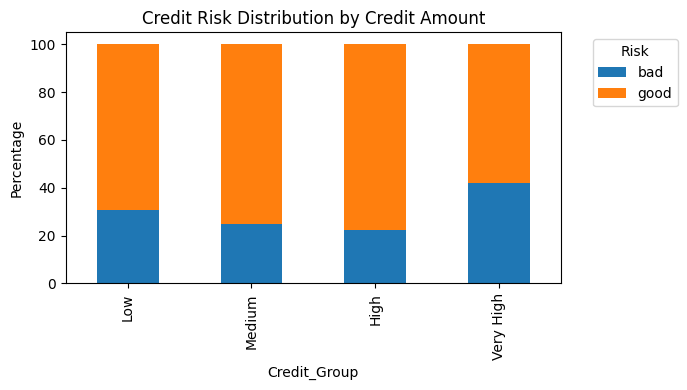

In [154]:
credit_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.ylabel("Percentage")
plt.title("Credit Risk Distribution by Credit Amount")
plt.legend(
    title="Risk",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

The average credit amount in the dataset is 3,271. Customers with bad credit risk have a substantially higher average loan amount (3,938) than customers with good credit risk (2,985). This finding suggests that larger loan amounts tend to be associated with higher credit risk. The boxplot also indicates that the bad-risk group has a wider distribution and a greater number of high-value loans, although the median credit amounts of the two groups are relatively similar. The histogram shows that most loans are concentrated between 2,000 and 4,000 units. When credit amounts were categorized into quartiles, the Very High loan group exhibited the highest proportion of bad credit risk (42.0%). However, the relationship is not strictly linear, as the Medium and High groups showed slightly lower risk proportions than the Low group. Overall, credit amount appears to be an important factor in credit risk assessment, particularly for customers requesting very large loans.

#### Job vs Risk

The relationship between employment skill level and credit risk was examined to determine whether occupational status is associated with different credit risk profiles.

In [155]:
df["Job"].value_counts()

Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64

In [156]:
df["Job"].value_counts(normalize=True)*100

Job
2    63.0
1    20.0
3    14.8
0     2.2
Name: proportion, dtype: float64

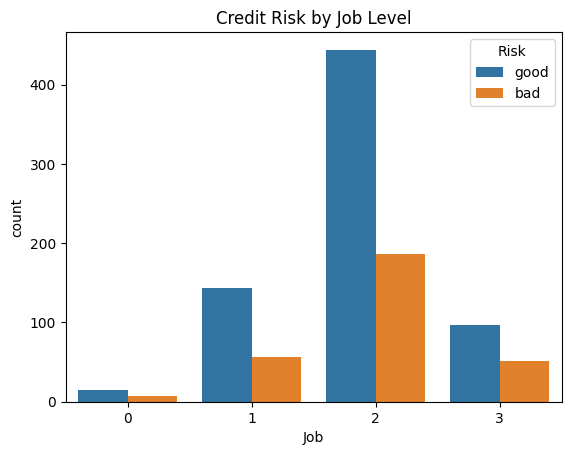

In [157]:
sns.countplot(
    data=df,
    x="Job",
    hue="Risk"
)

plt.title("Credit Risk by Job Level")
plt.show()

In [158]:
job_risk = pd.crosstab(
    df["Job"],
    df["Risk"],
    normalize="index"
)*100

job_risk

Risk,bad,good
Job,,
0,31.818182,68.181818
1,28.000000,72.000000
2,29.523810,70.476190
3,34.459459,65.540541


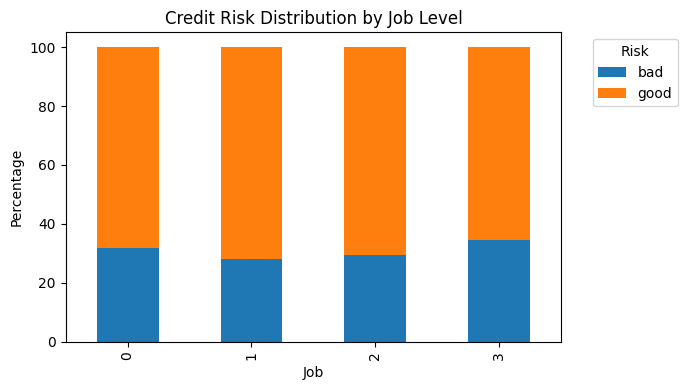

In [159]:
job_risk.plot(
    kind="bar",
    stacked=True,
    figsize=(7,4)
)

plt.ylabel("Percentage")
plt.title("Credit Risk Distribution by Job Level")

plt.legend(
    title="Risk",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Skilled workers (Job 2) represented the largest occupational group, accounting for 63% of customers. However, the percentage distribution of credit risk across job categories showed only limited variation. The highest proportion of bad credit risk was observed among highly skilled workers (34.5%), while unskilled resident workers (Job 1) exhibited the lowest risk level (28.0%). Overall, job category does not appear to be a strong standalone predictor of credit risk in this dataset.

Unlike age, duration, credit amount, saving account, and checking account variables, the job variable showed relatively weak discrimination between good and bad credit risk groups.

## Feature Encoding

Before correlation analysis and machine learning modeling, categorical variables were converted into numerical representations to make them suitable for statistical analysis and algorithm training.

### 1. Target Variable Encoding

In [160]:
df["Risk_Numeric"] = df["Risk"].map({
    "good": 0,
    "bad": 1
})

df[["Risk","Risk_Numeric"]].head()

,Risk,Risk_Numeric
0,good,0
1,bad,1
2,good,0
3,good,0
4,bad,1


The target variable was encoded as 0 for good credit risk and 1 for bad credit risk, enabling its use in correlation analysis and machine learning algorithms.

### 2. Ordinal Encoding

In [161]:
saving_map = {
    "no_account": 0,
    "little": 1,
    "moderate": 2,
    "quite rich": 3,
    "rich": 4
}

df["Saving_accounts_encoded"] = df["Saving accounts"].map(saving_map)

df[["Saving accounts","Saving_accounts_encoded"]].head()

,Saving accounts,Saving_accounts_encoded
0,no_account,0
1,little,1
2,little,1
3,little,1
4,little,1


In [162]:
checking_map = {
    "no_account": 0,
    "little": 1,
    "moderate": 2,
    "rich": 3
}

df["Checking_account_encoded"] = df["Checking account"].map(checking_map)

df[["Checking account","Checking_account_encoded"]].head()

,Checking account,Checking_account_encoded
0,little,1
1,moderate,2
2,no_account,0
3,little,1
4,little,1


Since saving account status and checking account status have a natural order representing increasing financial capacity, these variables were encoded using ordinal mapping instead of one-hot encoding.

### 3. Nominal Variable Encoding (One-Hot Encoding)

In [163]:
df_encoded = pd.get_dummies(
    df,
    columns=["Sex","Housing","Purpose"],
    drop_first=True,
    dtype=int
)

df_encoded.head()

,Age,Job,Saving accounts,Checking account,Credit amount,Duration,Risk,Age_Group,Duration_Group,Credit_Group,...,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,no_account,little,1169,6,good,60+,Short (<=12),Low,...,1,1,0,0,0,0,0,1,0,0
1,22,2,little,moderate,5951,48,bad,18-30,Very Long (37+),Very High,...,0,1,0,0,0,0,0,1,0,0
2,49,1,little,no_account,2096,12,good,41-50,Short (<=12),Medium,...,1,1,0,0,0,1,0,0,0,0
3,45,2,little,little,7882,42,good,41-50,Very Long (37+),Very High,...,1,0,0,0,0,0,1,0,0,0
4,53,2,little,little,4870,24,bad,51-60,Medium (13-24),Very High,...,1,0,0,1,0,0,0,0,0,0


Nominal variables, including sex, housing status, and loan purpose, were transformed using one-hot encoding to convert categorical values into binary features while avoiding artificial ordinal relationships. The drop_first=True option was applied to reduce multicollinearity by removing one reference category from each variable.

## Correlation Analysis

In [164]:
corr_matrix = df_encoded.corr(numeric_only=True)

corr_matrix.head()

,Age,Job,Credit amount,Duration,Risk_Numeric,Saving_accounts_encoded,Checking_account_encoded,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
Age,1.000000,0.015673,0.032716,-0.036136,-0.091127,-0.017997,-0.049058,0.161694,0.006553,-0.212620,0.099919,-0.012562,0.060390,-0.127657,-0.046401,0.039567,0.042365
Job,0.015673,1.000000,0.285385,0.210910,0.032735,-0.040803,-0.054255,0.070298,-0.059393,-0.039195,0.036762,-0.025979,-0.021672,0.013422,-0.027683,-0.092751,0.100544
Credit amount,0.032716,0.285385,1.000000,0.624984,0.154739,-0.107538,0.024561,0.093482,-0.117497,-0.024611,0.125575,-0.069268,-0.034796,-0.034037,-0.173203,-0.028875,0.192893
Duration,-0.036136,0.210910,0.624984,1.000000,0.214927,-0.064526,0.035050,0.081432,-0.075169,-0.064417,-0.005320,-0.037212,-0.025450,-0.062804,-0.044319,-0.022549,0.104516
Risk_Numeric,-0.091127,0.032735,0.154739,0.214927,1.000000,-0.033871,0.197788,-0.075493,-0.134589,0.092785,0.022621,0.008016,0.049085,0.020971,-0.106922,0.020828,0.028058


### Heatmap

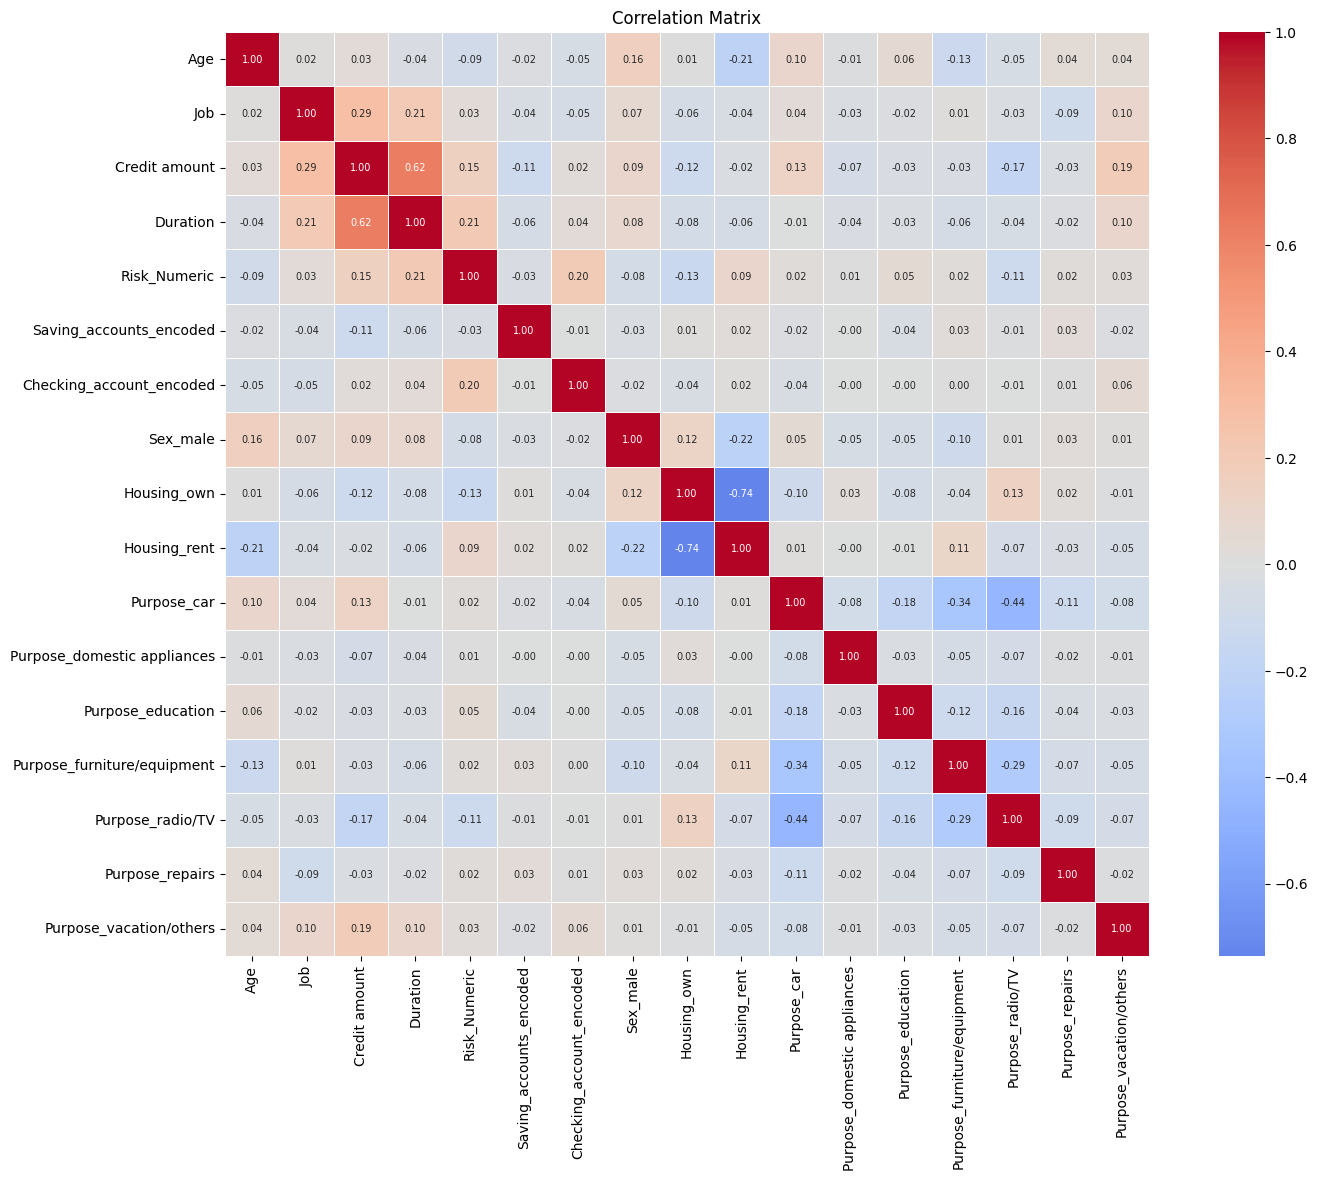

In [165]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size":7}
)

plt.title("Correlation Matrix")
plt.show()

Correlation analysis indicates that loan duration (r = 0.21), checking account status (r = 0.20), and credit amount (r = 0.15) exhibit the strongest positive relationships with credit risk. In contrast, home ownership (r = -0.13), radio/TV loan purpose (r = -0.11), and age (r = -0.09) show weak negative correlations, suggesting that older customers and homeowners tend to have slightly lower credit risk.

Credit amount and loan duration show a moderately strong positive correlation (r = 0.62), indicating that customers requesting larger loans generally choose longer repayment periods.

### Correlation of Features with Credit Risk

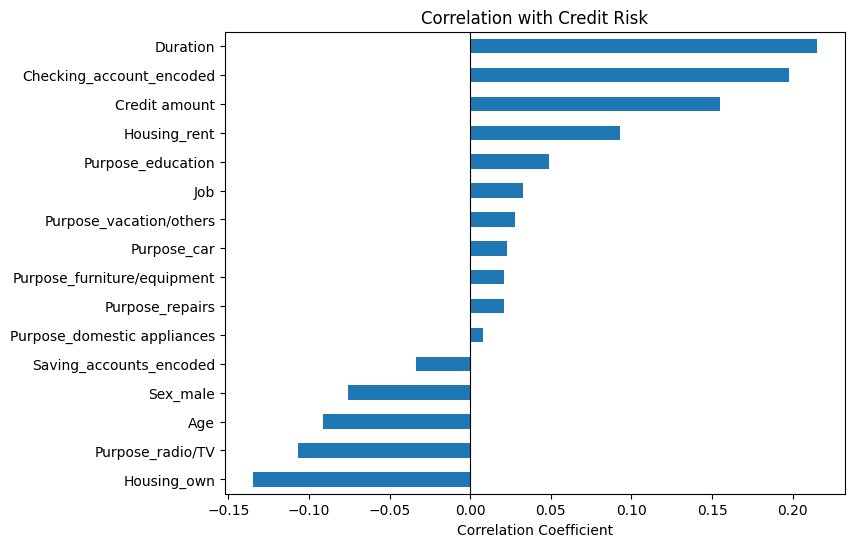

In [166]:
risk_corr = (
    corr_matrix["Risk_Numeric"]
    .drop("Risk_Numeric")
    .sort_values()
)

plt.figure(figsize=(8,6))
risk_corr.plot(kind="barh")
plt.axvline(0, color="black", linewidth=0.8)

plt.title("Correlation with Credit Risk")
plt.xlabel("Correlation Coefficient")
plt.show()

Although Duration, Checking Account Status, and Credit Amount have the highest correlations with credit risk, all correlation coefficients remain below 0.30, indicating weak linear relationships. Therefore, no single variable alone explains credit risk, and the prediction task requires the combined effect of multiple features.

### Train-Test Split

In [167]:
df_encoded = df_encoded.drop(
    columns=["Saving accounts", "Checking account", "Risk","Age_Group", "Duration_Group","Credit_Group"])

The dataset was divided into training (80%) and testing (20%) sets using stratified sampling to preserve the original class distribution and ensure an unbiased evaluation of the machine learning models.

In [168]:
X= df_encoded.drop(columns=["Risk_Numeric"])
y= df_encoded["Risk_Numeric"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 16)
(200, 16)


### Feature Scaling

In [169]:
numeric_cols = ["Age", "Duration", "Credit amount"]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

Continuous variables were standardized to have zero mean and unit variance to improve the performance of distance-based and linear machine learning algorithms.

## Machine Learning Modeling

The encoded dataset was divided into training (80%) and testing (20%) sets using stratified sampling. Continuous variables were standardized using StandardScaler before training the Logistic Regression model to ensure comparable feature scales and improve optimization performance.

### 1.Logistic Regression (Balanced)

Logistic Regression was selected as a baseline classification model due to its simplicity and interpretability.

Since the dataset contains an imbalanced class distribution (700 good vs. 300 bad credit risks), the `class_weight="balanced"` parameter was applied to assign higher importance to the minority class during training.

#### Model

In [170]:
log_reg = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### Prediction

In [171]:
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]

#### Classification Report

In [172]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.67      0.73       140
           1       0.43      0.58      0.50        60

    accuracy                           0.65       200
   macro avg       0.61      0.63      0.61       200
weighted avg       0.68      0.65      0.66       200



The model achieved higher performance in predicting the majority class (good credit risk) with an F1-score of 0.73, while the minority class (bad credit risk) obtained an F1-score of 0.50. The balanced class weighting improved the recall of bad credit cases (58%), although precision remained relatively low (43%).

#### Confusion Matrix

Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

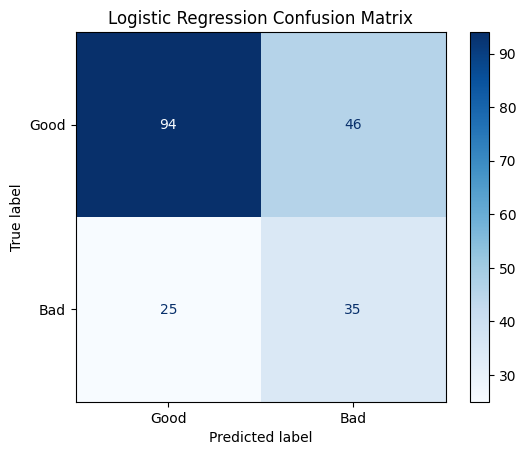

In [173]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Good","Bad"]
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")


The confusion matrix shows that 94 good credit cases and 35 bad credit cases were correctly classified. However, 46 good customers were misclassified as bad, and 25 bad customers were incorrectly predicted as good. This indicates that the balanced model prioritizes detecting bad credit cases at the cost of increasing false positives.

#### Performance Metrics

In [174]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.3f}")

Accuracy : 0.645
Precision: 0.432
Recall   : 0.583
F1 Score : 0.496
ROC AUC  : 0.673


The Logistic Regression model achieved an accuracy of 64.5% and a ROC-AUC score of 0.673. Although the overall accuracy is moderate, the balanced configuration improves the identification of bad credit customers, which is important for credit risk assessment.

#### Roc-Curve

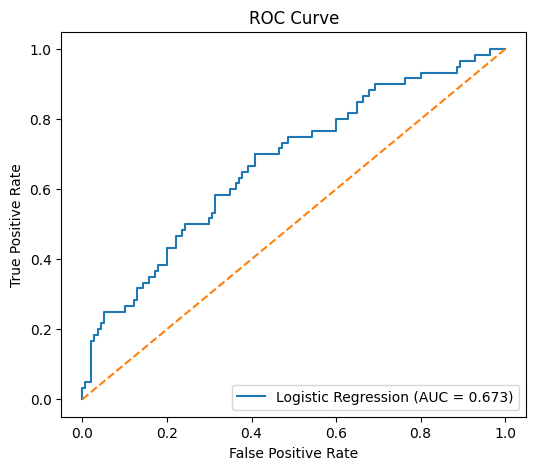

In [175]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

The ROC curve lies above the diagonal reference line, indicating that the model performs better than random guessing. The ROC-AUC value of 0.673 suggests a moderate ability to distinguish between good and bad credit risks.

Overall, the balanced Logistic Regression model provides a reasonable baseline for credit risk prediction. While it successfully improves the detection of the minority class, its overall predictive performance remains moderate, suggesting that more advanced machine learning models may achieve better discrimination between good and bad credit risks.

### 2. Desicion Tree (Balanced)

Decision Tree was selected as a non-linear classification model capable of capturing complex decision boundaries and interactions between variables. Similar to Logistic Regression, class balancing was applied to reduce the impact of class imbalance.

#### Model

In [176]:
dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    max_depth=5
)

dt.fit(X_train,y_train)



,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


#### Prediction

In [177]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

#### Classification Report

In [178]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.86      0.69      0.76       140
           1       0.51      0.75      0.60        60

    accuracy                           0.70       200
   macro avg       0.69      0.72      0.68       200
weighted avg       0.76      0.70      0.72       200



Decision Tree achieved better classification performance than Logistic Regression across both classes. The model obtained an F1-score of 0.76 for good credit risk and 0.60 for bad credit risk. The recall value of 75% for the bad credit class indicates that the model successfully identified three out of four high-risk customers.

#### Confusion Matrix

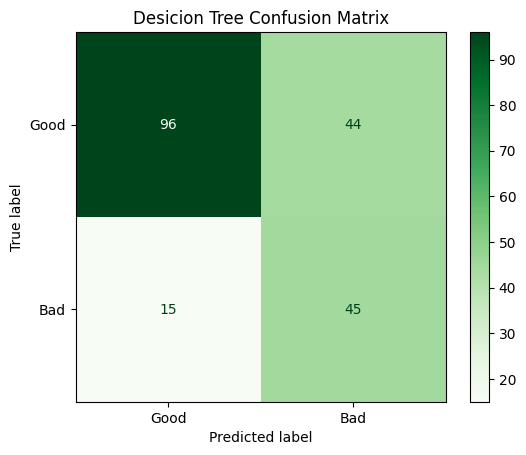

In [179]:
cm_dt = confusion_matrix(y_test,y_pred_dt)

disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Good", "Bad"]
)

disp_dt.plot(cmap="Greens")

plt.title("Desicion Tree Confusion Matrix")
plt.show()

The confusion matrix shows that the model correctly classified 96 good credit customers and 45 bad credit customers. Compared with Logistic Regression, the number of correctly identified bad credit cases increased from 35 to 45, while false negatives decreased from 25 to 15. This improvement demonstrates the Decision Tree model's stronger ability to detect risky customers.

#### Performance Metrics

In [180]:
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_dt):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred_dt):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_dt):.3f}")

Accuracy : 0.705
Precision: 0.506
Recall   : 0.750
F1 Score : 0.604
ROC AUC  : 0.768


The Decision Tree model achieved an Accuracy of 70.5%, Precision of 50.6%, Recall of 75.0%, F1-score of 60.4%, and ROC-AUC of 0.768. Compared with Logistic Regression, improvements were observed across all evaluation metrics, indicating a better balance between identifying risky customers and maintaining overall classification performance.

#### ROC Curve

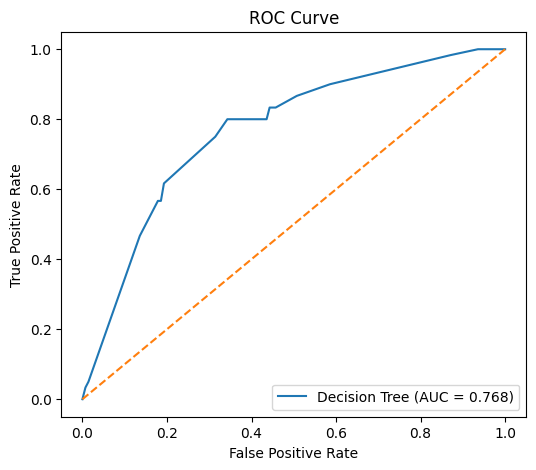

In [181]:
fpr_dt, tpr_dt, _ = roc_curve(y_test,y_prob_dt)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test,y_prob_dt):.3f})"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

The ROC curve is positioned well above the diagonal reference line, indicating that the model performs substantially better than random classification. The AUC value of 0.768 suggests that the Decision Tree provides good discriminative ability and outperforms the Logistic Regression baseline model.

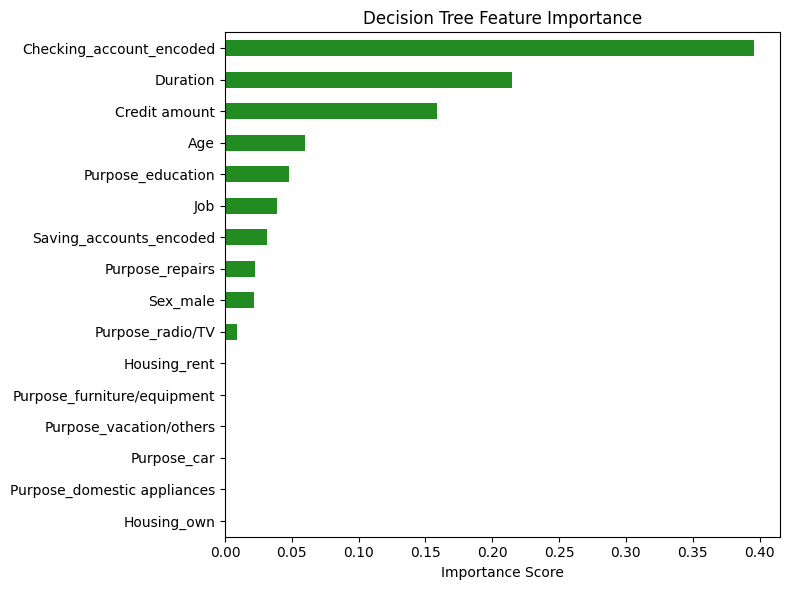

In [182]:
dt_importance = pd.Series(
    dt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8,6))

dt_importance.plot(
    kind="barh",
    color="forestgreen"
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()

The Decision Tree feature importance analysis indicates that Checking Account Status is the most influential predictor of credit risk, followed by Loan Duration and Credit Amount. These findings are consistent with the exploratory data analysis and correlation results, suggesting that customers' financial account status and loan characteristics contribute more to credit risk prediction than demographic variables such as age or job level. Variables related to loan purpose and housing status showed relatively low importance, indicating a limited contribution to the model's decision-making process.

### Random Forest (Balanced)

Random Forest was selected as an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting. To address the class imbalance problem, the class_weight="balanced" parameter was applied during model training.

#### Model

In [183]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Prediction

In [184]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

#### Classification Report 

In [185]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.74      0.78       140
           1       0.51      0.62      0.56        60

    accuracy                           0.70       200
   macro avg       0.66      0.68      0.67       200
weighted avg       0.73      0.70      0.71       200



The Random Forest model achieved an F1-score of **0.78** for the majority class (good credit risk) and **0.56** for the minority class (bad credit risk). Compared with Logistic Regression, the model showed improved precision for identifying bad credit applicants (0.51) while maintaining a recall of 0.62. The weighted F1-score of **0.71** indicates a balanced overall classification performance.


#### Confusion Matrix

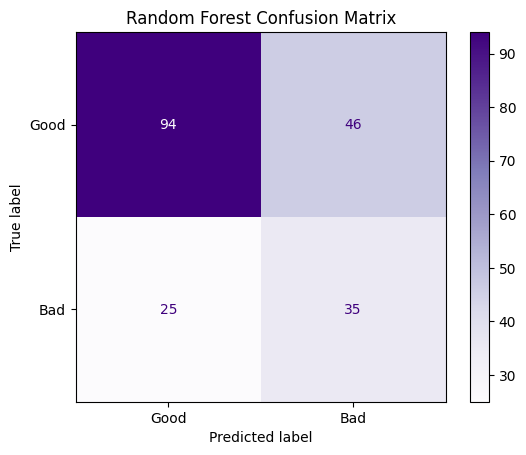

In [186]:
cm_rf = confusion_matrix(y_test,y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels= ["Good","Bad"]
)

disp_rf.plot(cmap="Purples")

plt.title("Random Forest Confusion Matrix")
plt.show()

The confusion matrix shows that the Random Forest model correctly classified **94 good credit applicants** and **35 bad credit applicants**. However, **46 good credit customers were incorrectly predicted as bad**, while **25 bad credit customers were misclassified as good**. Overall, the model demonstrates a reasonable ability to identify both classes while reducing misclassification errors compared with the baseline model.


#### Performance Metrics

In [187]:
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_rf):.3f}")

Accuracy : 0.705
Precision: 0.507
Recall   : 0.617
F1 Score : 0.556
ROC AUC  : 0.771


#### ROC Curve 

The Random Forest model achieved an **accuracy of 70.5%**, indicating that approximately seven out of ten applicants were classified correctly. The model obtained a **precision of 50.7%**, meaning that about half of the applicants predicted as bad credit were actually bad credit cases. The **recall of 61.7%** shows that the model successfully identified more than sixty percent of actual bad credit customers. An **F1-score of 0.556** reflects a balanced trade-off between precision and recall, while the **ROC-AUC score of 0.771** indicates a good overall ability to distinguish between good and bad credit risks.


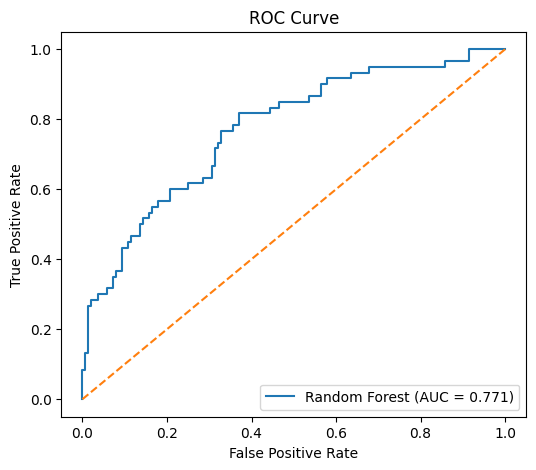

In [188]:
fpr_rf, tpr_rf, _ = roc_curve(y_test,y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test,y_prob_rf):.3f})"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

The ROC curve lies clearly above the diagonal reference line, demonstrating that the Random Forest model performs better than random guessing. The **AUC value of 0.771** suggests a good discriminative ability and represents the highest ROC-AUC score among the evaluated models, indicating that Random Forest provides the strongest overall separation between good and bad credit applicants.


#### Feature Importance

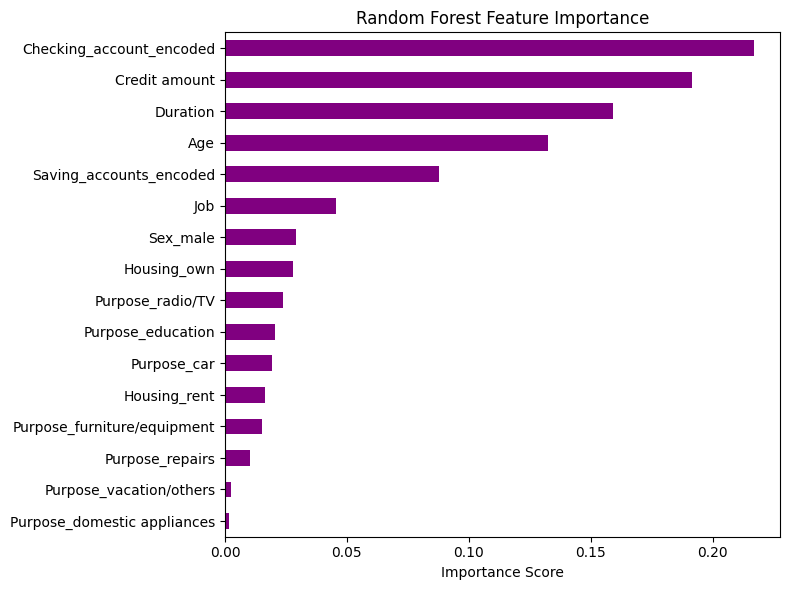

In [189]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,6))

rf_importance.plot(
    kind="barh",
    color="purple"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

### XGBoost

XGBoost was employed as an advanced gradient boosting algorithm that builds decision trees sequentially to improve prediction performance by correcting previous errors. Since the dataset contains an imbalanced class distribution (700 good vs. 300 bad credit risks), the scale_pos_weight parameter was applied to assign greater importance to the minority class during training.

#### Model Training 

In [190]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

scale_pos_weight

np.float64(2.3333333333333335)

In [191]:
xgb = XGBClassifier(
    n_estimators = 200,
    max_depth = 4,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    eval_metric = "logloss"
)

xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


#### Prediction

In [192]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

#### Classification Report 

In [193]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.83      0.75      0.79       140
           1       0.53      0.65      0.58        60

    accuracy                           0.72       200
   macro avg       0.68      0.70      0.69       200
weighted avg       0.74      0.72      0.73       200



The XGBoost model achieved an F1-score of 0.79 for the majority class (good credit risk) and 0.58 for the minority class (bad credit risk). Compared with the previous models, it improved precision and overall classification performance while preserving a balanced ability to identify bad credit applicants. The weighted F1-score of 0.73 suggests satisfactory overall performance, although prediction accuracy remains higher for good credit applicants than for bad credit applicants.

#### Consufion Matrix 

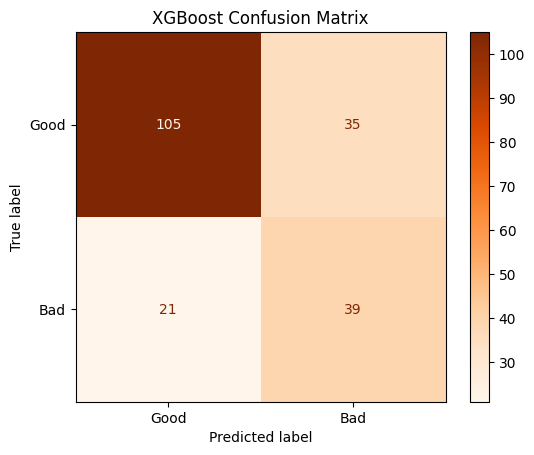

In [194]:
cm_xgb = confusion_matrix(y_test,y_pred_xgb)

disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Good", "Bad"]
)

disp_xgb.plot(cmap="Oranges")
plt.title("XGBoost Confusion Matrix")
plt.show()

The confusion matrix shows that the XGBoost model correctly classified 105 good credit applicants and 39 bad credit applicants. Meanwhile, 35 good credit customers were incorrectly classified as bad, and 21 bad credit customers were misclassified as good. Compared with the other evaluated models, XGBoost reduced the number of false negatives while increasing the number of correctly identified good credit applicants, resulting in a more balanced classification performance.

#### Performance Metrics

In [195]:
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred_xgb):.3f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_xgb):.3f}")

Accuracy : 0.720
Precision: 0.527
Recall   : 0.650
F1 Score : 0.582
ROC AUC  : 0.773


The XGBoost model achieved an accuracy of 72.0%, correctly classifying nearly three-quarters of the applicants. The model obtained a precision of 52.7%, indicating that more than half of the applicants predicted as bad credit were actually bad credit cases. The recall of 65.0% demonstrates that the model successfully identified approximately two-thirds of all bad credit applicants. Furthermore, the F1-score of 0.582 and ROC-AUC score of 0.773 indicate a balanced classification performance and the strongest overall discriminative ability among the evaluated models.

#### ROC Curve

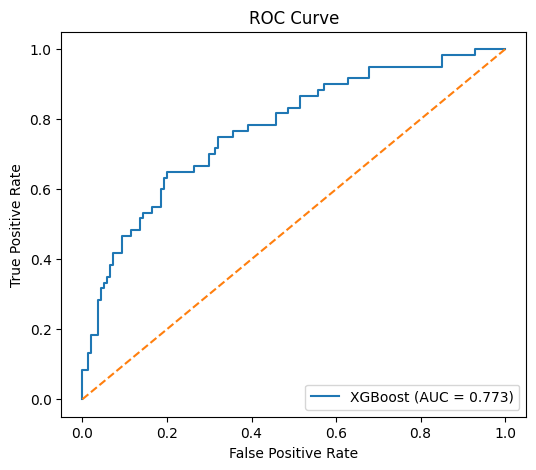

In [196]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_score(y_test,y_prob_xgb):.3f})"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

The ROC curve lies well above the diagonal reference line, confirming that the XGBoost model performs substantially better than random guessing. With an AUC value of 0.773, the model demonstrates the highest overall ability to distinguish between good and bad credit applicants among all evaluated classification models.

#### Feature Importance

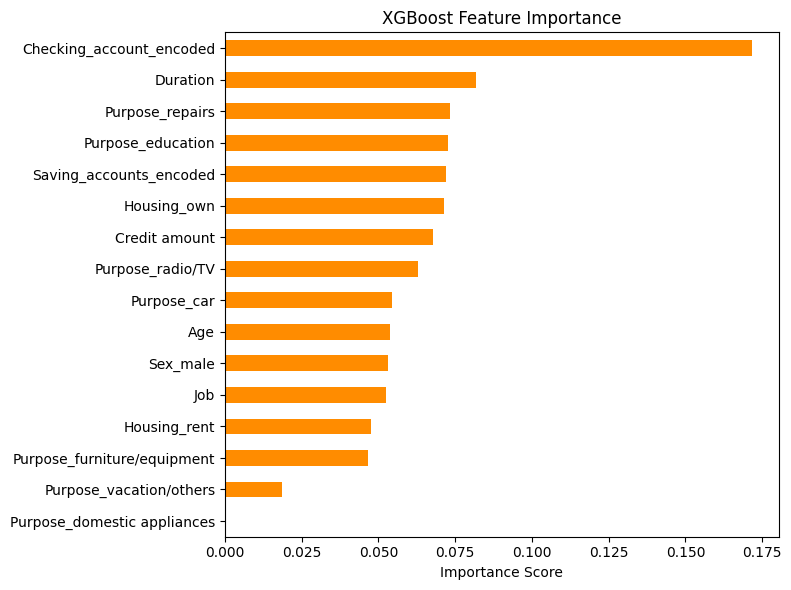

In [197]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,6))

xgb_importance.plot(
    kind="barh",
    color="darkorange"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

According to the XGBoost feature importance results, Checking Account Status is the dominant predictor of credit risk, followed by Loan Duration and Credit Amount. Although variables such as Saving Account Status, Housing Status, and Loan Purpose contribute to the model, their importance is substantially lower. These findings are consistent with the exploratory data analysis and previous tree-based models, confirming that applicants' financial conditions are the primary determinants of credit risk.

## Performance Comparison of Machine Learning Models

The performance of Logistic Regression, Decision Tree, Random Forest, and XGBoost models was compared using Accuracy, Precision, Recall, F1 Score, and ROC AUC metrics to identify the most suitable model for credit risk prediction.

In [198]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [0.645, 0.705, 0.705, 0.720],
    "Precision": [0.432, 0.506, 0.507, 0.527],
    "Recall": [0.583, 0.750, 0.617, 0.650],
    "F1 Score": [0.496, 0.604, 0.556, 0.582],
    "ROC AUC": [0.673, 0.768, 0.771, 0.773]
})


comparison = comparison.sort_values(
    by="Recall",
    ascending=False
)

comparison.style.highlight_max(
    subset=["Accuracy","Precision", "Recall","F1 Score","ROC AUC"],
    color="#AC8608"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,0.705000,0.506000,0.750000,0.604000,0.768000
3,XGBoost,0.720000,0.527000,0.650000,0.582000,0.773000
2,Random Forest,0.705000,0.507000,0.617000,0.556000,0.771000
0,Logistic Regression,0.645000,0.432000,0.583000,0.496000,0.673000


The comparison table shows that Decision Tree achieved the highest Recall (0.75) and F1 Score (0.60), indicating a stronger ability to identify bad credit applicants. In contrast, XGBoost obtained the highest Accuracy (0.72), Precision (0.53), and ROC AUC (0.773), demonstrating the best overall classification performance.

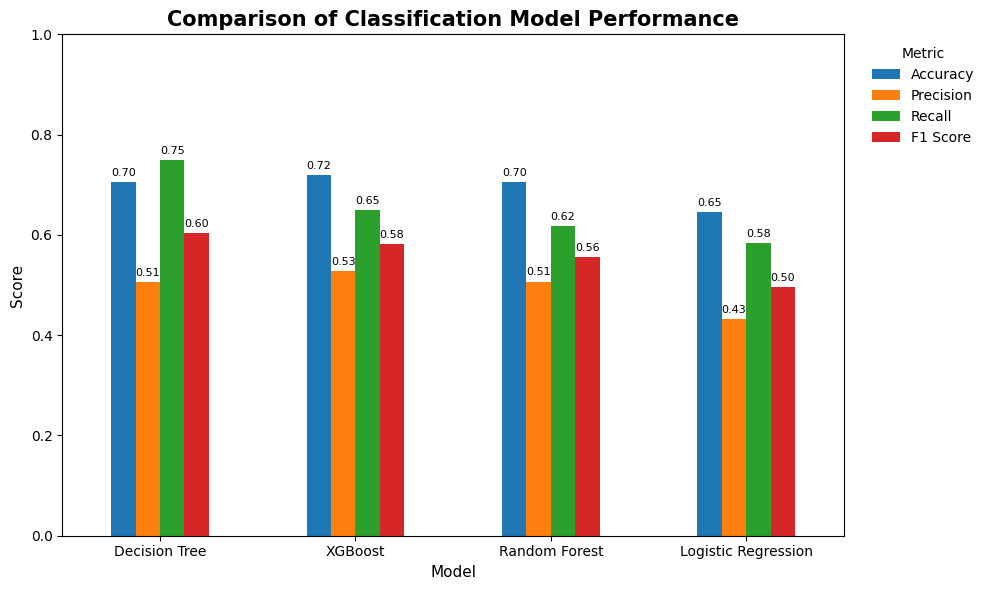

In [199]:
comparison_plot = comparison.set_index("Model")

ax = comparison_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

# Barların üzerine değerleri yazdır
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=8,
        padding=3
    )

# Başlık ve eksenler
plt.title(
    "Comparison of Classification Model Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Model", fontsize=11)
plt.ylabel("Score", fontsize=11)

# Eksen ayarları
plt.ylim(0, 1)
plt.xticks(rotation=0)

# Legend
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# Düzen
plt.tight_layout()

plt.show()

The performance comparison graph confirms that the three tree-based models exhibit very similar performance across the evaluation metrics, while Logistic Regression consistently performs at a lower level. Although XGBoost achieves slightly higher Accuracy and Precision, Decision Tree stands out with the highest Recall and F1 Score for the minority class. These findings suggest that the most suitable model should be selected according to the primary objective of the credit risk prediction task rather than relying on a single evaluation metric.

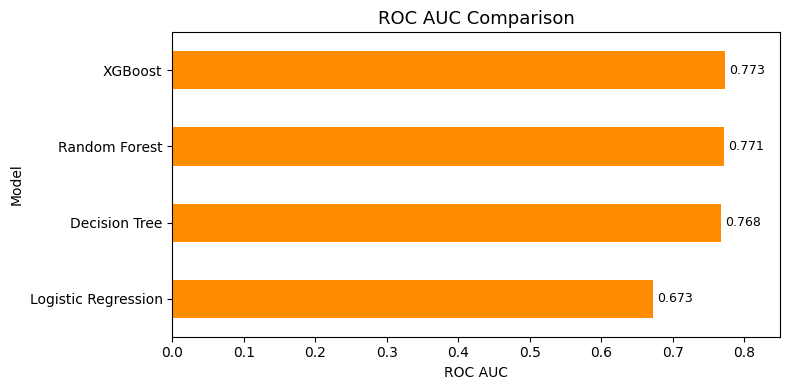

In [200]:
roc_plot = comparison.set_index("Model")

ax = roc_plot["ROC AUC"].sort_values().plot(
    kind="barh",
    figsize=(8,4),
    color="darkorange"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.title("ROC AUC Comparison", fontsize=13)
plt.xlabel("ROC AUC")
plt.ylabel("Model")

plt.xlim(0, 0.85)

plt.tight_layout()
plt.show()

XGBoost achieved the highest ROC AUC value (0.773), followed closely by Random Forest (0.771) and Decision Tree (0.768). The small differences suggest that all tree-based models have similar discrimination ability, while Logistic Regression performs noticeably worse.

## Comparison of Feature Importance Across Tree-Based Models

In [201]:
dt_importance = pd.Series(
    dt.feature_importances_,
    index=X_train.columns,
    name="Decision Tree"
)

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns,
    name="Random Forest"
)

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns,
    name="XGBoost"
)

In [202]:
importance_comparison = pd.concat(
    [
        dt_importance,
        rf_importance,
        xgb_importance
    ],
    axis=1
)

top_features = (
    importance_comparison.mean(axis=1)
    .sort_values(ascending=False)
    .head(5)
    .index
)

importance_comparison.loc[top_features]

importance_comparison.loc[top_features].style\
    .highlight_max(axis=1, color="#9B850D")\
    .format("{:.3f}")

,Decision Tree,Random Forest,XGBoost
Checking_account_encoded,0.396,0.217,0.172
Duration,0.214,0.159,0.082
Credit amount,0.158,0.191,0.068
Age,0.060,0.132,0.054
Saving_accounts_encoded,0.032,0.088,0.072


The feature importance comparison shows a consistent ranking of the most influential variables across the three tree-based models. Checking Account Status is identified as the most important predictor in all models, followed by Loan Duration and Credit Amount. Although the relative importance scores vary slightly, the overall ordering remains similar, suggesting that applicants' financial characteristics play a central role in credit risk prediction.

## Conclusion

This study explored credit risk prediction using four machine learning algorithms: Logistic Regression, Decision Tree, Random Forest, and XGBoost. Exploratory Data Analysis (EDA) indicated that applicants with longer loan durations, higher credit amounts, and weaker checking account status were more likely to be classified as bad credit risks. Correlation analysis and feature importance results consistently supported these findings, identifying Checking Account Status, Loan Duration, and Credit Amount as the most influential predictors.

The model comparison demonstrated that the three tree-based algorithms outperformed Logistic Regression across most evaluation metrics. XGBoost achieved the highest Accuracy (72.0%), Precision (52.7%), and ROC-AUC score (0.773), while Decision Tree obtained the highest Recall (75.0%) and F1 Score (0.60) for identifying bad credit applicants. Random Forest provided competitive and balanced performance across all evaluation metrics.

Overall, the findings suggest that the most appropriate model depends on the primary objective of the credit risk prediction task. When maximizing overall predictive performance is the priority, XGBoost is the preferred choice. However, if identifying as many high-risk applicants as possible is the main objective, Decision Tree offers the highest recall and may be a more suitable alternative. The results also emphasize the importance of applicants' financial characteristics over demographic variables in assessing credit risk.

## Business Recommendations

Based on the findings of this study, financial institutions should place greater emphasis on applicants' checking account status, loan duration, and requested credit amount during the credit evaluation process. These variables consistently emerged as the most important predictors across exploratory analysis and multiple machine learning models.

Although Decision Tree achieved the highest recall for bad credit applicants, XGBoost demonstrated the best overall predictive performance and is therefore recommended as the primary model for automated credit risk assessment. Implementing such models can help financial institutions reduce default risk, improve lending decisions, and allocate financial resources more efficiently.

Future studies may further improve prediction performance by incorporating additional customer information, such as employment history, income level, repayment behavior, or external credit bureau data.